In [ ]:
# Kaggle setup (quiet install to keep logs readable)
%pip install -q datasets transformers accelerate pyarrow more-itertools

# Optional: only needed if you run the GPN model
# %pip install -q git+https://github.com/songlab-cal/gpn.git

In [1]:
import gc
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import concatenate_datasets, load_dataset
#from more_itertools import batched
#from transformers import AutoModel, AutoTokenizer
#from transformers.models.bert.configuration_bert import BertConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA count: {torch.cuda.device_count()}")

Device: cpu


In [2]:
CONFIG = {
    "dataset_name": "katarinagresova/Genomic_Benchmarks_demo_coding_vs_intergenomic_seqs",
    "output_root": "./mutation_sensitivity_outputs",
    # Full mutation grid for analysis
    "mutation_percents": list(range(5, 101, 5)),
    "num_mutations_per_percent": 100,
    "batch_size": 64,
    "chunk_size": 256,
    "max_length": 200,
    "run_coding": True,
    "run_noncoding": True,
    # Balanced subsampling controls (must match prior run)
    "subsample_enabled": True,
    "samples_per_label": 500,
    "subsample_strategy": "first",  # "first" or "random"
    "subsample_seed": 42,
    # Optional hard cap after filtering/subsampling
    "sequence_limit": None,
    # Save mutated strings alongside distance rows
    "save_mutated_sequences": True,
    "resume": True,
}

# Resolve to an existing local Windows folder if available.
_output_candidates = [
    Path(CONFIG["output_root"]),
    Path.cwd() / "mutation_sensitivity_outputs",
    Path.cwd() / "Mutation Sensitivity" / "GB sequences" / "mutation_sensitivity_outputs",
    Path(r"c:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\GB sequences\mutation_sensitivity_outputs"),
]

for candidate in _output_candidates:
    if candidate.exists():
        CONFIG["output_root"] = str(candidate.resolve())
        break

print(f"Using output_root: {CONFIG['output_root']}")
CONFIG

Using output_root: C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\GB sequences\mutation_sensitivity_outputs


{'dataset_name': 'katarinagresova/Genomic_Benchmarks_demo_coding_vs_intergenomic_seqs',
 'output_root': 'C:\\Users\\Ruhaib\\Downloads\\IIT Stuff\\Research\\BiSECT Lab\\Model Evaluation\\Mutation Sensitivity\\GB sequences\\mutation_sensitivity_outputs',
 'mutation_percents': [5,
  10,
  15,
  20,
  25,
  30,
  35,
  40,
  45,
  50,
  55,
  60,
  65,
  70,
  75,
  80,
  85,
  90,
  95,
  100],
 'num_mutations_per_percent': 100,
 'batch_size': 64,
 'chunk_size': 256,
 'max_length': 200,
 'run_coding': True,
 'run_noncoding': True,
 'subsample_enabled': True,
 'samples_per_label': 500,
 'subsample_strategy': 'first',
 'subsample_seed': 42,
 'sequence_limit': None,
 'save_mutated_sequences': True,
 'resume': True}

In [ ]:
dataset = load_dataset(CONFIG["dataset_name"])
train_dataset = dataset["train"]
test_dataset = dataset["test"]
full_dataset = concatenate_datasets([train_dataset, test_dataset])

all_seqs = full_dataset["seq"]
all_labels = full_dataset["label"]

meta_df = pd.DataFrame({
    "seq": all_seqs,
    "label": all_labels,
})
meta_df["orig_index"] = np.arange(len(meta_df), dtype=np.int32)

selected_labels = []
if CONFIG["run_coding"]:
    selected_labels.append(0)
if CONFIG["run_noncoding"]:
    selected_labels.append(1)
if len(selected_labels) == 0:
    raise ValueError("Both run_coding and run_noncoding are False. Nothing to run.")

meta_df = meta_df[meta_df["label"].isin(selected_labels)].reset_index(drop=True)

if CONFIG.get("subsample_enabled", False):
    strategy = str(CONFIG.get("subsample_strategy", "first")).lower()
    per_label = int(CONFIG.get("samples_per_label", 500))
    sampled_parts = []

    for label in selected_labels:
        label_df = meta_df[meta_df["label"] == label]
        take_n = min(per_label, len(label_df))

        if strategy == "first":
            label_sample = label_df.head(take_n)
        elif strategy == "random":
            label_sample = label_df.sample(n=take_n, random_state=CONFIG.get("subsample_seed", SEED))
        else:
            raise ValueError("subsample_strategy must be 'first' or 'random'.")

        sampled_parts.append(label_sample)

    if len(sampled_parts) == 0:
        raise ValueError("No rows available after subsampling.")

    meta_df = pd.concat(sampled_parts, ignore_index=True)

    if strategy == "random":
        meta_df = meta_df.sample(frac=1.0, random_state=CONFIG.get("subsample_seed", SEED)).reset_index(drop=True)

if CONFIG["sequence_limit"] is not None:
    meta_df = meta_df.head(min(CONFIG["sequence_limit"], len(meta_df))).copy()

lengths = pd.Series([len(s) for s in meta_df["seq"]]).value_counts().sort_index()
print(f"Total selected sequences: {len(meta_df)}")
print("Label counts (0=coding, 1=non-coding):")
print(meta_df["label"].value_counts().sort_index())
print("Observed sequence lengths:")
print(lengths.to_dict())
print(
    f"Subsample mode: {CONFIG.get('subsample_strategy', 'first')} | "
    f"samples_per_label: {CONFIG.get('samples_per_label', 'NA')}"
)

([200], 37500, 37500)

In [ ]:
DNA_BASES = ["A", "T", "C", "G"]

def mutater(percent, seq):
    """Exact mutation logic from your script (optimized version)."""
    seq_length = len(seq)
    mutation_number = round(percent * seq_length / 100)
    mutation_number = min(mutation_number, seq_length)

    mutation_positions = random.sample(range(seq_length), mutation_number)
    seq_list = list(seq)

    for i in mutation_positions:
        og_base = seq_list[i]
        new_base = random.choice(DNA_BASES)
        while new_base == og_base:
            new_base = random.choice(DNA_BASES)
        seq_list[i] = new_base

    return "".join(seq_list)

def generate_mutations_for_percent(seq, percent, num_mutations):
    return [mutater(percent, seq) for _ in range(num_mutations)]

def build_mutation_batch(sequences, percent, num_mutations):
    """
    Returns:
      mutated_sequences: flat list of mutated strings
      parent_indices: index of source sequence in `sequences` for each mutated sequence
      mutation_instance: 0..num_mutations-1 repeated for each source sequence
    """
    mutated_sequences = []
    parent_indices = []
    mutation_instance = []

    for seq_idx, seq in enumerate(sequences):
        variants = generate_mutations_for_percent(seq, percent, num_mutations)
        mutated_sequences.extend(variants)
        parent_indices.extend([seq_idx] * num_mutations)
        mutation_instance.extend(range(num_mutations))

    return mutated_sequences, np.array(parent_indices), np.array(mutation_instance)

In [3]:
MODEL_SPECS = [
    ["GROVER", "PoetschLab/GROVER", "mean"],
    ["DNABERT-2", "zhihan1996/DNABERT-2-117M", "pooler"],
    ["GPN", "songlab/gpn-brassicales", "mean"],
    ["NT500M", "InstaDeepAI/nucleotide-transformer-500m-human-ref", "mean"],
    ["NT2.5B-MS", "InstaDeepAI/nucleotide-transformer-2.5b-multi-species", "mean"],
    ["NT2.5B-1K", "InstaDeepAI/nucleotide-transformer-2.5b-1000g", "mean"],
    ["Hyena-1k", "LongSafari/hyenadna-tiny-1k-seqlen-hf", "mean"],
    ["Hyena-16k", "LongSafari/hyenadna-tiny-16k-seqlen-d128-hf", "mean"],
    ["Hyena-32k", "LongSafari/hyenadna-small-32k-seqlen-hf", "mean"],
    ["GenaLM", "AIRI-Institute/gena-lm-bigbird-base-t2t", "mean"],
    ["DNABERT-S", "zhihan1996/DNABERT-S", "pooler"],
    ["Hyena-160k", "LongSafari/hyenadna-medium-160k-seqlen-hf", "mean"],
    ["Hyena-450k", "LongSafari/hyenadna-medium-450k-seqlen-hf", "mean"],
    ["Hyena-1m", "LongSafari/hyenadna-large-1m-seqlen-hf", "mean"],
]

# Recovery run: only NT500M
MODELS_TO_RUN = ["GROVER", "Hyena-1k", "Hyena-16k", "Hyena-32k", "GenaLM", "NT500M"]

model_map = {name: {"hf_id": hf_id, "pooling": pooling} for name, hf_id, pooling in MODEL_SPECS}
selected_model_specs = [{"name": name, **model_map[name]} for name in MODELS_TO_RUN]
selected_model_specs

[{'name': 'GROVER', 'hf_id': 'PoetschLab/GROVER', 'pooling': 'mean'},
 {'name': 'Hyena-1k',
  'hf_id': 'LongSafari/hyenadna-tiny-1k-seqlen-hf',
  'pooling': 'mean'},
 {'name': 'Hyena-16k',
  'hf_id': 'LongSafari/hyenadna-tiny-16k-seqlen-d128-hf',
  'pooling': 'mean'},
 {'name': 'Hyena-32k',
  'hf_id': 'LongSafari/hyenadna-small-32k-seqlen-hf',
  'pooling': 'mean'},
 {'name': 'GenaLM',
  'hf_id': 'AIRI-Institute/gena-lm-bigbird-base-t2t',
  'pooling': 'mean'},
 {'name': 'NT500M',
  'hf_id': 'InstaDeepAI/nucleotide-transformer-500m-human-ref',
  'pooling': 'mean'}]

### Mutation Sensitivity Pipeline
This notebook runs the mutation robustness experiment on the Genomic Benchmarks coding vs intergenomic dataset.

Default run mode is a balanced 1000-sequence subset (500 coding + 500 non-coding), configurable through the CONFIG cell.

For each selected model and each input sequence, it does:
1. Original embedding
2. For each mutation percentage (5 to 100 by 5), generate 100 point-mutated variants
3. Generate batched embeddings for the mutated variants
4. Compute Euclidean distance to the original embedding
5. Save rows to parquet including metadata, mutated sequence string, and distance

In [ ]:
def load_model_and_tokenizer(model_spec):
    model_name = model_spec["hf_id"]
    pooling = model_spec["pooling"]

    print(f"Loading {model_spec['name']} from {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    if model_name == "zhihan1996/DNABERT-2-117M":
        config = BertConfig.from_pretrained("zhihan1996/DNABERT-2-117M")
        model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
            config=config,
        ).to(device)
    else:
        model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        ).to(device)

    model.eval()
    return tokenizer, model, pooling

'\n#if using a kaggle dataset\n\ngenes = {}\n\nfrom Bio import SeqIO\nfrom pathlib import Path\n\ndirectory = "/kaggle/input/100-genes"\n\nfor filename in Path(directory).glob("*.fasta"):\n    sequences = []\n\n    for sequence in SeqIO.parse(filename, "fasta"):\n        sequences.append(str(sequence.seq))\n        \n    genes[f"{str(filename).split(\'/\')[-1].rstrip(\'.fasta\')}"] = sequences\n'

In [ ]:
def generate_batched_embeddings(tokenizer, model, pooling, sequences, batch_size, max_length):
    embeddings = []
    total = len(sequences)
    done = 0

    for batch in batched(sequences, batch_size):
        batch = list(batch)
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        if pooling == "pooler":
            if isinstance(outputs, (tuple, list)) and len(outputs) > 1 and outputs[1] is not None:
                result = outputs[1]
            else:
                result = outputs.last_hidden_state[:, 0, :]
        else:
            result = outputs.last_hidden_state.mean(dim=1)

        embeddings.append(result.detach().cpu().numpy().astype(np.float32))

        done += len(batch)
        if done % (batch_size * 50) == 0 or done == total:
            print(f"    Embedded {done}/{total} sequences")

    return np.concatenate(embeddings, axis=0)

In [ ]:
def run_mutation_sensitivity_for_model(model_spec, work_df, config):
    output_root = Path(config["output_root"])
    output_root.mkdir(parents=True, exist_ok=True)
    model_output_dir = output_root / model_spec["name"]
    model_output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer, model, pooling = load_model_and_tokenizer(model_spec)

    chunk_size = config["chunk_size"]
    num_chunks = math.ceil(len(work_df) / chunk_size)
    save_mutated_sequences = config.get("save_mutated_sequences", True)

    print(f"Running model: {model_spec['name']}")
    print(f"Total sequences: {len(work_df)} | Chunks: {num_chunks}")

    model_start = time.time()

    for chunk_id in range(num_chunks):
        start_idx = chunk_id * chunk_size
        end_idx = min((chunk_id + 1) * chunk_size, len(work_df))
        chunk_df = work_df.iloc[start_idx:end_idx]

        seq_chunk = chunk_df["seq"].tolist()
        label_chunk = chunk_df["label"].to_numpy(dtype=np.int8)
        global_idx_chunk = chunk_df["orig_index"].to_numpy(dtype=np.int32)

        expected_files = [
            model_output_dir / f"chunk_{chunk_id:06d}_pct_{pct:03d}.parquet"
            for pct in config["mutation_percents"]
        ]
        if config["resume"] and all(p.exists() for p in expected_files):
            print(f"  Skipping chunk {chunk_id + 1}/{num_chunks} (already complete)")
            continue

        print(f"  Processing chunk {chunk_id + 1}/{num_chunks} (size={len(seq_chunk)})")
        original_embeddings = generate_batched_embeddings(
            tokenizer=tokenizer,
            model=model,
            pooling=pooling,
            sequences=seq_chunk,
            batch_size=config["batch_size"],
            max_length=config["max_length"],
        )

        for pct in config["mutation_percents"]:
            out_file = model_output_dir / f"chunk_{chunk_id:06d}_pct_{pct:03d}.parquet"
            if config["resume"] and out_file.exists():
                continue

            mutated_sequences, parent_indices, mutation_instance = build_mutation_batch(
                seq_chunk,
                percent=pct,
                num_mutations=config["num_mutations_per_percent"],
            )

            mutated_embeddings = generate_batched_embeddings(
                tokenizer=tokenizer,
                model=model,
                pooling=pooling,
                sequences=mutated_sequences,
                batch_size=config["batch_size"],
                max_length=config["max_length"],
            )

            distances = np.linalg.norm(
                mutated_embeddings - original_embeddings[parent_indices],
                axis=1,
            ).astype(np.float32)

            labels_for_rows = label_chunk[parent_indices]
            seq_type = np.where(labels_for_rows == 0, "coding", "non-coding")

            out_df = pd.DataFrame({
                "model": model_spec["name"],
                "global_sequence_index": global_idx_chunk[parent_indices],
                "label": labels_for_rows,
                "sequence_type": seq_type,
                "mutation_percent": np.full(len(distances), pct, dtype=np.int16),
                "mutation_instance": mutation_instance.astype(np.int16),
                "distance": distances,
            })

            if save_mutated_sequences:
                out_df["mutated_sequence"] = mutated_sequences

            out_df.to_parquet(out_file, index=False)

            del mutated_sequences, parent_indices, mutation_instance, mutated_embeddings, distances, out_df
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            print(f"    Saved: {out_file.name}")

        del original_embeddings
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    model_end = time.time()
    print(f"Completed {model_spec['name']} in {round(model_end - model_start, 2)} seconds")

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
# Build dataframe actually used by the run loop
work_df = meta_df[["orig_index", "seq", "label"]].copy().reset_index(drop=True)
work_df["sequence_type"] = np.where(work_df["label"] == 0, "coding", "non-coding")

print(work_df.head())
print(work_df["sequence_type"].value_counts())

In [ ]:
# Optional: if using GPN, uncomment this line
# import gpn.model

In [ ]:
overall_start = time.time()

for model_spec in selected_model_specs:
    run_mutation_sensitivity_for_model(model_spec, work_df, CONFIG)

overall_end = time.time()
print(f"All requested models completed in {round(overall_end - overall_start, 2)} seconds")
print(f"Outputs written to: {CONFIG['output_root']}")

In [4]:
# Build an index of generated distance files and quick sanity stats
output_root = Path(CONFIG["output_root"])
records = []
for model_dir in sorted(output_root.glob("*")):
    if not model_dir.is_dir():
        continue
    for pq in sorted(model_dir.glob("*.parquet")):
        records.append({"model": model_dir.name, "file": str(pq)})

manifest_df = pd.DataFrame(records)
manifest_path = output_root / "distance_file_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print(f"Manifest saved: {manifest_path}")
print(f"Parquet files found: {len(manifest_df)}")
display(manifest_df.head())

if len(manifest_df) > 0:
    sample = pd.read_parquet(manifest_df.iloc[0]["file"])
    print("Sample rows from first parquet:")
    display(sample.head())
    print("Columns in saved rows:")
    print(sample.columns.tolist())
    if "mutated_sequence" in sample.columns:
        print("Mutated sequences are present in output rows.")
    print("Distance summary:")
    display(sample.groupby(["sequence_type", "mutation_percent"])["distance"].describe().head())

Manifest saved: C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\GB sequences\mutation_sensitivity_outputs\distance_file_manifest.csv
Parquet files found: 480


,model,file
0,GenaLM,C:\Users\Ruhaib\Downloads\IIT Stuff\Research\B...
1,GenaLM,C:\Users\Ruhaib\Downloads\IIT Stuff\Research\B...
2,GenaLM,C:\Users\Ruhaib\Downloads\IIT Stuff\Research\B...
3,GenaLM,C:\Users\Ruhaib\Downloads\IIT Stuff\Research\B...
4,GenaLM,C:\Users\Ruhaib\Downloads\IIT Stuff\Research\B...


Sample rows from first parquet:


,model,global_sequence_index,label,sequence_type,mutation_percent,mutation_instance,distance,mutated_sequence
0,GenaLM,37500,0,coding,5,0,1.569093,TGGCCGGCCTCGATTTAAAGAGACAGAAGCTGTCGGAGTCCTGAAA...
1,GenaLM,37500,0,coding,5,1,1.672531,TGGCTGGCCTCGATTTAAAGAGACAGAAGCTGACGGGGTCCTGGAA...
2,GenaLM,37500,0,coding,5,2,1.438044,TGGGTGGCCTCGATTTAAAGAGACAGAAGCTGTCGGGGTCCTGGTA...
3,GenaLM,37500,0,coding,5,3,1.677957,TGGCTGGCCTCGATTTAAAGAGACAGAAGCTGTCGGGGTCCTCGTA...
4,GenaLM,37500,0,coding,5,4,1.439757,TGGCTGGCCTCGATTTAAAAAGCCAGAAGCCGTCGGAGTCCTGGAA...


Columns in saved rows:
['model', 'global_sequence_index', 'label', 'sequence_type', 'mutation_percent', 'mutation_instance', 'distance', 'mutated_sequence']
Mutated sequences are present in output rows.
Distance summary:


,,count,mean,std,min,25%,50%,75%,max
sequence_type,mutation_percent,,,,,,,,
coding,5,25600.0,2.032929,0.616659,0.831445,1.593871,1.901885,2.332703,5.949999


Reading parquet files from: C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\GB sequences\mutation_sensitivity_outputs
GROVER: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


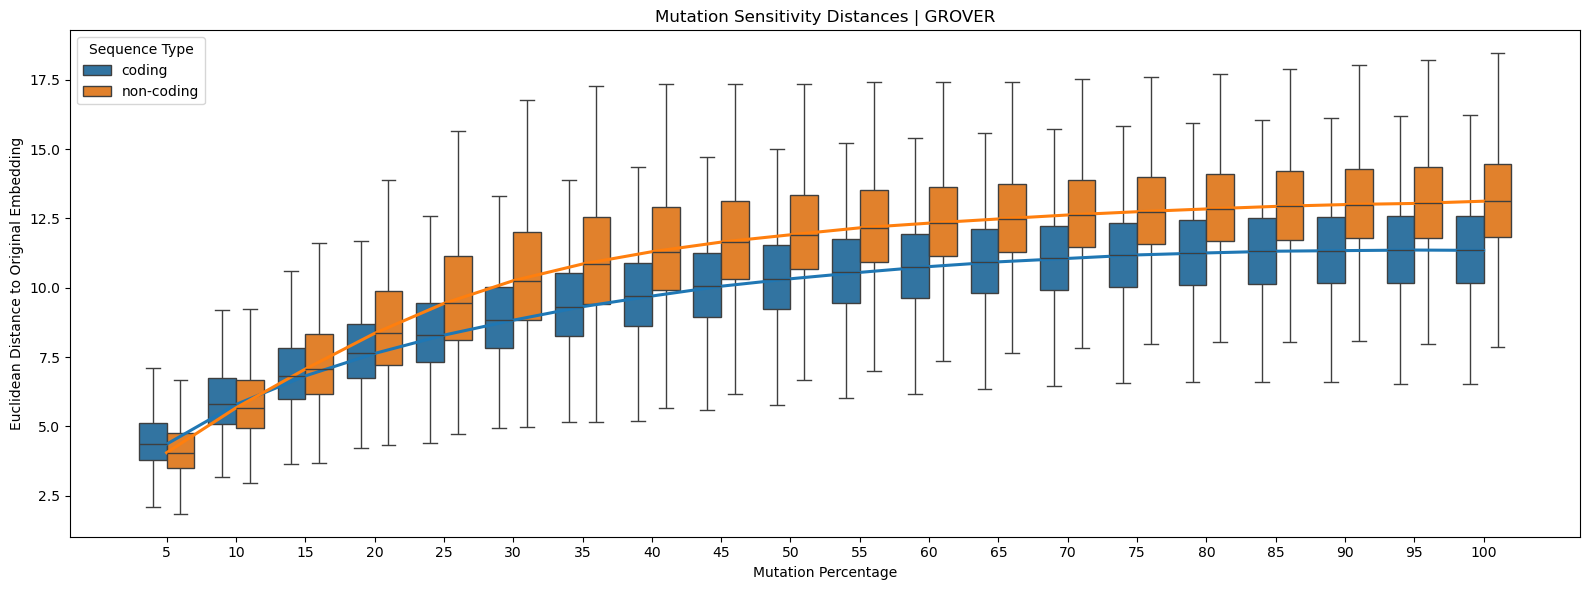

Hyena-1k: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


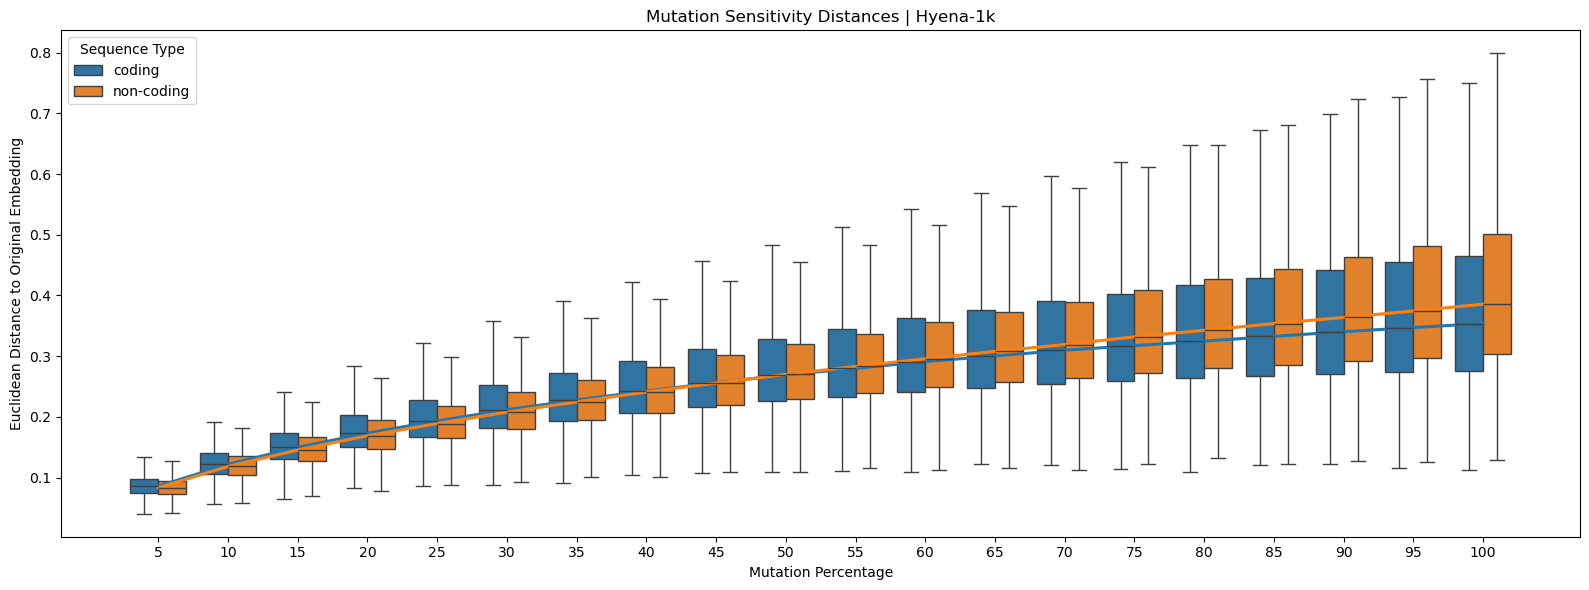

Hyena-16k: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


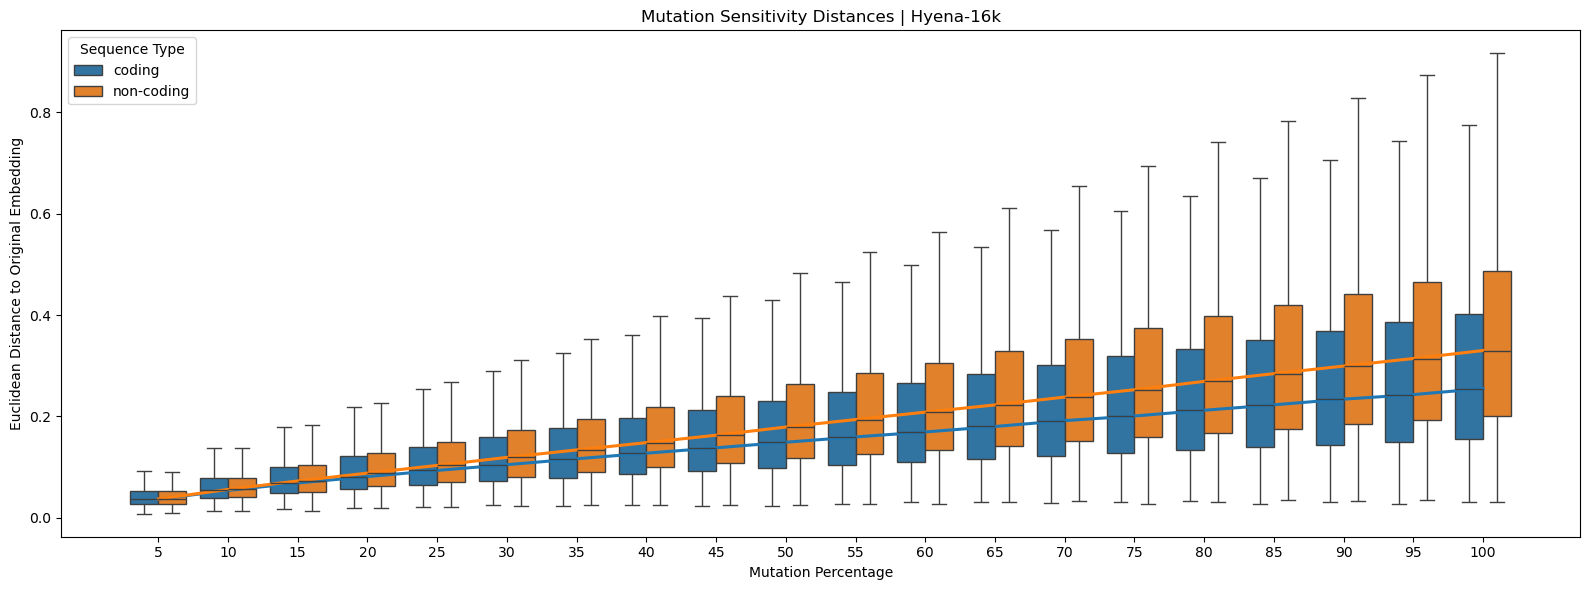

Hyena-32k: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


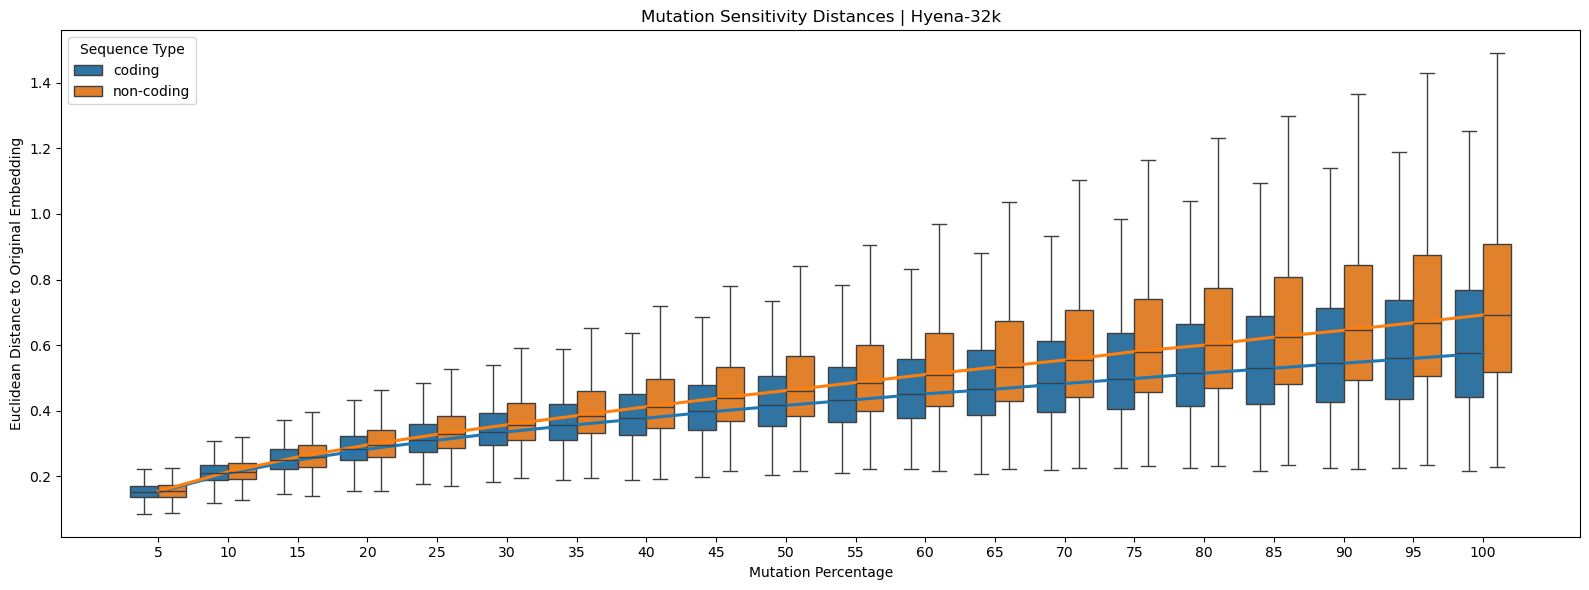

GenaLM: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


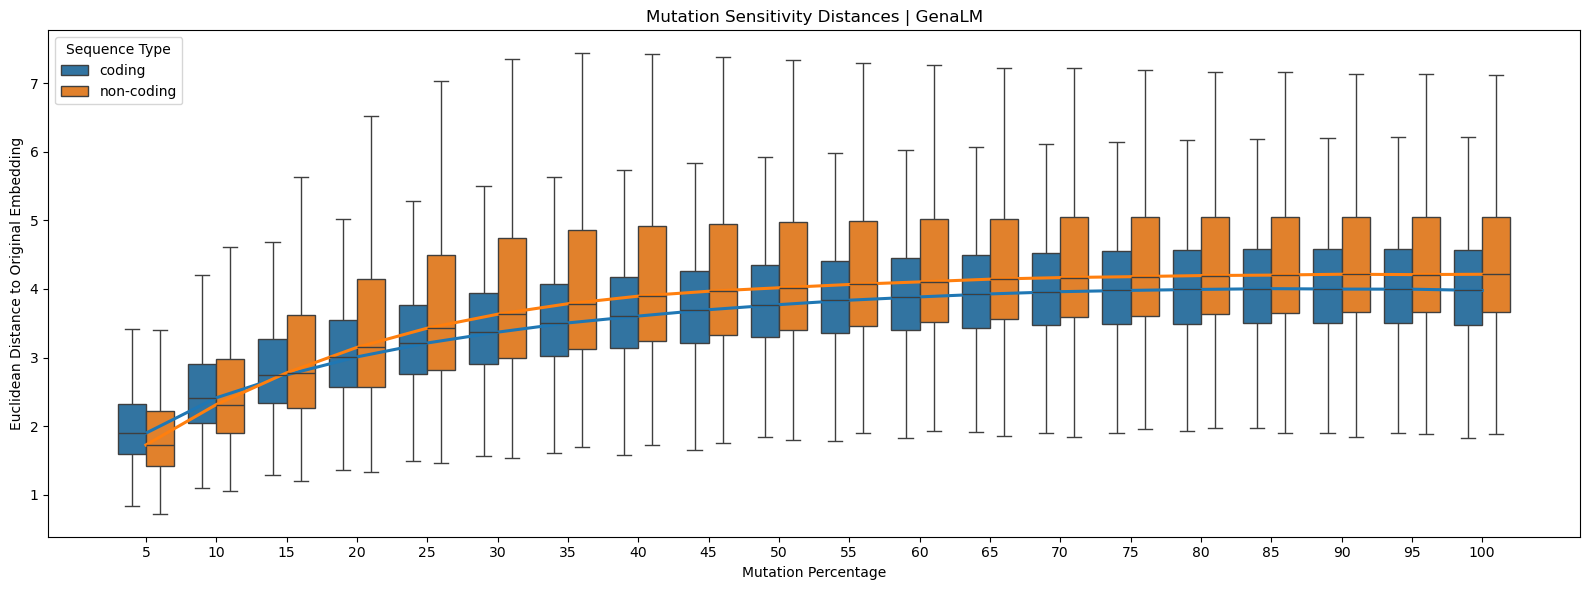

NT500M: loaded 80 files | 2000000 rows


C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_27684\3933298012.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]


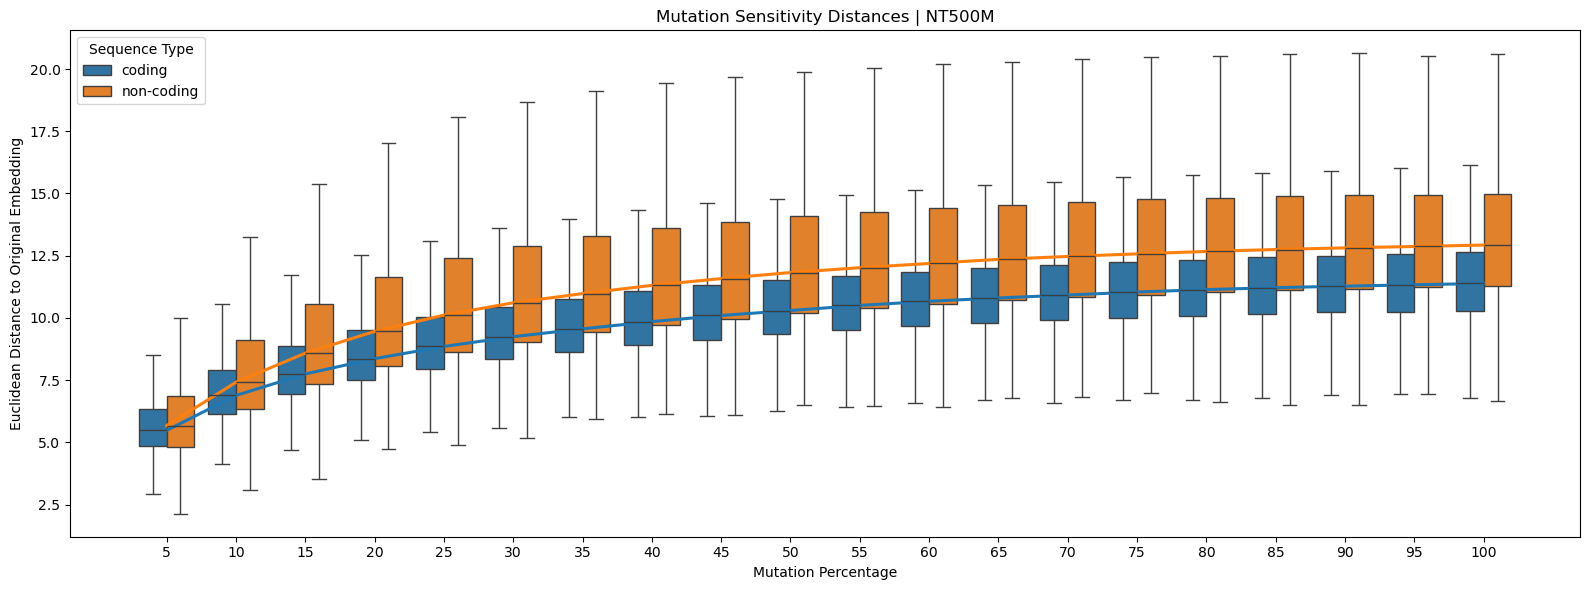

In [5]:
# Quick boxplot helper from locally saved parquet files (Windows-friendly)
import matplotlib.pyplot as plt
import seaborn as sns

output_root = Path(CONFIG["output_root"]).expanduser().resolve()
print(f"Reading parquet files from: {output_root}")

# Use one model name (string) or a list of model names.
PLOT_MODELS = MODELS_TO_RUN
MAX_ROWS_FOR_PLOT = 2_000_000  # Downsample for interactive plotting if needed
CONNECT_MEDIANS = True

if isinstance(PLOT_MODELS, str):
    plot_models = [PLOT_MODELS]
else:
    plot_models = list(PLOT_MODELS)

plotted_any = False

for model_name in plot_models:
    model_files = sorted((output_root / model_name).glob("*.parquet"))
    if len(model_files) == 0:
        print(f"No parquet files found for model: {model_name}")
        continue

    model_df = pd.concat([pd.read_parquet(f) for f in model_files], ignore_index=True)
    print(f"{model_name}: loaded {len(model_files)} files | {len(model_df)} rows")

    if len(model_df) > MAX_ROWS_FOR_PLOT:
        model_df = model_df.sample(MAX_ROWS_FOR_PLOT, random_state=SEED)
        print(f"{model_name}: downsampled to {len(model_df)} rows")

    model_df = model_df.dropna(subset=["mutation_percent", "distance", "sequence_type"]).copy()
    model_df["mutation_percent"] = model_df["mutation_percent"].astype(int)

    pct_order = sorted(model_df["mutation_percent"].unique().tolist())
    pct_labels = [str(p) for p in pct_order]
    model_df["mutation_percent_str"] = model_df["mutation_percent"].astype(str)
    model_df["mutation_percent_str"] = pd.Categorical(
        model_df["mutation_percent_str"],
        categories=pct_labels,
        ordered=True,
    )

    plt.figure(figsize=(16, 6))
    ax = sns.boxplot(
        data=model_df,
        x="mutation_percent_str",
        y="distance",
        hue="sequence_type",
        showfliers=False,
        order=pct_labels,
    )

    if CONNECT_MEDIANS:
        median_df = (
            model_df.groupby(["mutation_percent_str", "sequence_type"], as_index=False)["distance"]
            .median()
        )
        sns.lineplot(
            data=median_df,
            x="mutation_percent_str",
            y="distance",
            hue="sequence_type",
            estimator=None,
            markers=True,
            dashes=False,
            linewidth=2.2,
            sort=False,
            legend=False,
            ax=ax,
        )

    ax.set_title(f"Mutation Sensitivity Distances | {model_name}")
    ax.set_xlabel("Mutation Percentage")
    ax.set_ylabel("Euclidean Distance to Original Embedding")

    handles, labels = ax.get_legend_handles_labels()
    dedup = {}
    for handle, label in zip(handles, labels):
        if label not in dedup:
            dedup[label] = handle
    ax.legend(dedup.values(), dedup.keys(), title="Sequence Type")

    plt.tight_layout()
    plt.show()
    plotted_any = True

if not plotted_any:
    print("No parquet files found yet for plotting.")